<a href="https://colab.research.google.com/github/artemsorokin120504-star/-2026-103-/blob/main/Lab08_telecom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Упражнение 8

### Окно Гаусса

Сравним **прямоугольное окно (boxcar)** и **гауссово окно (Gaussian window)**.

Гауссово окно имеет форму колоколообразной кривой и определяется формулой:

$$
w(t) = e^{-\frac{1}{2} \left( \frac{t - \mu}{\sigma} \right)^2}
$$

где:
- $\mu$ — центр окна,
- $\sigma$ — определяет ширину окна (дисперсию).

В отличие от прямоугольного окна, у гауссова окна **плавные границы**, что:
- уменьшает утечки спектра (spectral leakage),
- делает его более подходящим для анализа нестационарных сигналов.

Далее сравним их визуально и спектрально.



### Построение прямоугольного окна (boxcar window)

Создадим **прямоугольное окно** — простейший тип оконной функции, в котором все значения внутри окна равны 1, а за пределами — 0.

Оно часто используется в базовом спектральном анализе, однако обладает высокой утечкой спектра из-за резких краёв.


In [2]:
import os
if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
from thinkdsp import normalize, unbias, read_wave, PinkNoise, decorate, UncorrelatedGaussianNoise, Spectrum, Wave, Noise
import matplotlib.pyplot as plt
import numpy as np
import scipy
boxcar = np.ones(11)
boxcar /= sum(boxcar)

### Построение гауссовского окна

Создадим гауссовское окно — оконную функцию с формой колоколообразной кривой.  
В отличие от прямоугольного окна, оно имеет плавные края, что помогает уменьшить спектральные искажения (утечки).

Гауссовское окно определяется длиной окна (N) и параметром ширины (sigma), который регулирует степень сглаживания краёв.


In [ ]:
import scipy

gaussian = scipy.signal.windows.gaussian(M=11, std=2)
gaussian /= sum(gaussian)

Построим оба окна


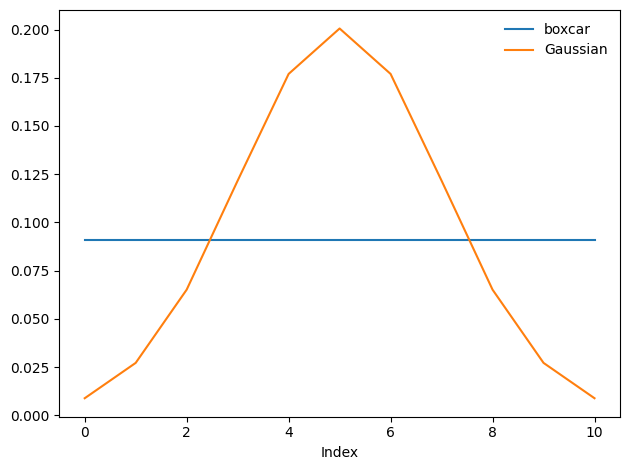

In [ ]:
plt.plot(boxcar, label='boxcar')
plt.plot(gaussian, label='Gaussian')
decorate(xlabel='Index')

Свёртка квадратной волны с гауссовым окном


In [ ]:
ys = np.convolve(wave.ys, gaussian, mode='same')
smooth = Wave(ys, framerate=wave.framerate)
spectrum2 = smooth.make_spectrum()

Вычисление отношения амплитуд


In [ ]:
amps = spectrum.amps
amps2 = spectrum2.amps
ratio = amps2 / amps
ratio[amps<560] = 0

Вычисление БПФ окна


In [ ]:
padded =  zero_pad(gaussian, len(wave))
dft_gaussian = np.fft.rfft(padded)

Построение графиков отношений и БПФ окна

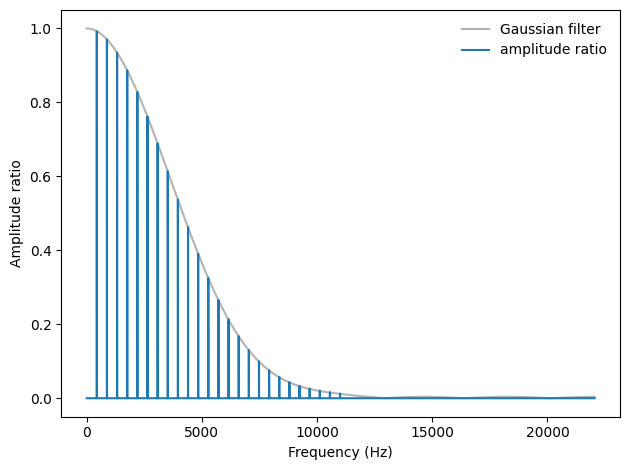

In [ ]:
plt.plot(np.abs(dft_gaussian), color='0.7', label='Gaussian filter')
plt.plot(ratio, label='amplitude ratio')

decorate(xlabel='Frequency (Hz)', ylabel='Amplitude ratio')

Объединение предыдущего примера в одну функцию для интерактивности

In [ ]:
from thinkdsp import SquareSignal

def plot_filter(M=11, std=2):
    signal = SquareSignal(freq=440)
    wave = signal.make_wave(duration=1, framerate=44100)
    spectrum = wave.make_spectrum()

    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= sum(gaussian)

    ys = np.convolve(wave.ys, gaussian, mode='same')
    smooth =  Wave(ys, framerate=wave.framerate)
    spectrum2 = smooth.make_spectrum()

    # plot the ratio of the original and smoothed spectrum
    amps = spectrum.amps
    amps2 = spectrum2.amps
    ratio = amps2 / amps
    ratio[amps<560] = 0

    # plot the same ratio along with the FFT of the window
    padded =  zero_pad(gaussian, len(wave))
    dft_gaussian = np.fft.rfft(padded)

    plt.plot(np.abs(dft_gaussian), color='gray', label='Gaussian filter')
    plt.plot(ratio, label='amplitude ratio')

    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude ratio')
    plt.show()

Попробуем различные значения `M` и `std`








In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.IntSlider(min=2, max=100, value=11)
slider2 = widgets.FloatSlider(min=0, max=20, value=2)
interact(plot_filter, M=slider, std=slider2);

interactive(children=(IntSlider(value=11, description='M', min=2), FloatSlider(value=2.0, description='std', m…

### Вопрос

Что произойдёт, если при увеличении ширины гауссова окна `std` не увеличивать число элементов в окне `M`?

### Ответ

Если увеличивать `std`, не увеличивая размер окна `M`, значительная часть гауссовой функции будет «обрезана» краями окна. Это приведёт к тому, что окно перестанет быть гладким и симметричным, и могут появиться артефакты в спектре (например, боковые лепестки усилятся), поскольку с точки зрения частотного анализа окно уже не будет напоминать настоящее гауссово.

Таким образом, для сохранения корректной формы и свойств окна при увеличении `std` следует пропорционально увеличивать `M`.


## Упражнение 8.2

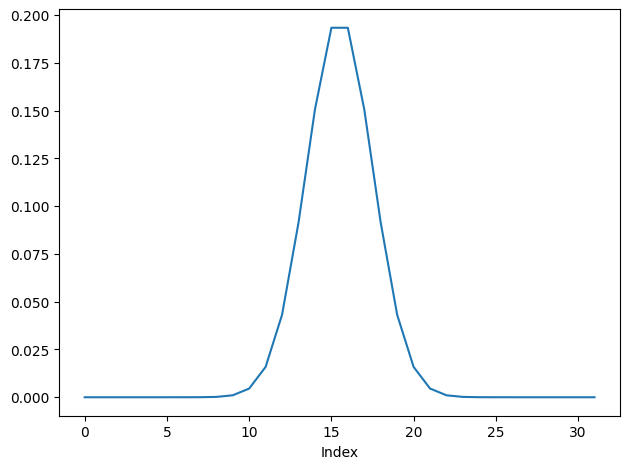

In [ ]:
from scipy.signal.windows import gaussian as g

gaussian = g(M=32, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
decorate(xlabel='Index')

### Вот как выглядит БПФ

Ниже представлено изображение спектра, полученного с помощью быстрого преобразования Фурье (FFT).
Оно показывает распределение частотных компонентов сигнала.


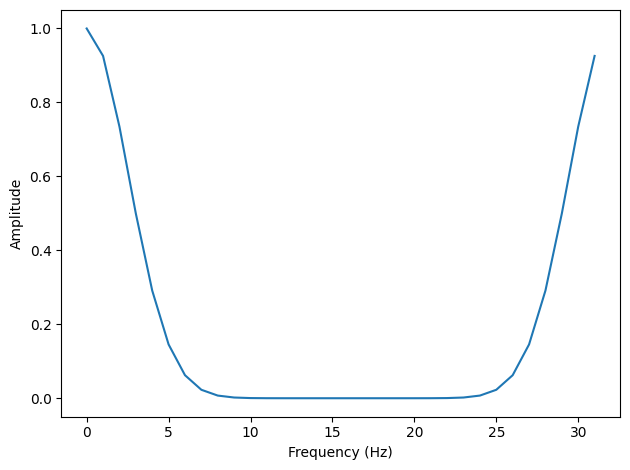

In [ ]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

### Если перенести отрицательные частоты влево

Если сдвинуть отрицательные частоты влево (в начало спектра), можно более наглядно увидеть, что форма спектра приближается к гауссовой.


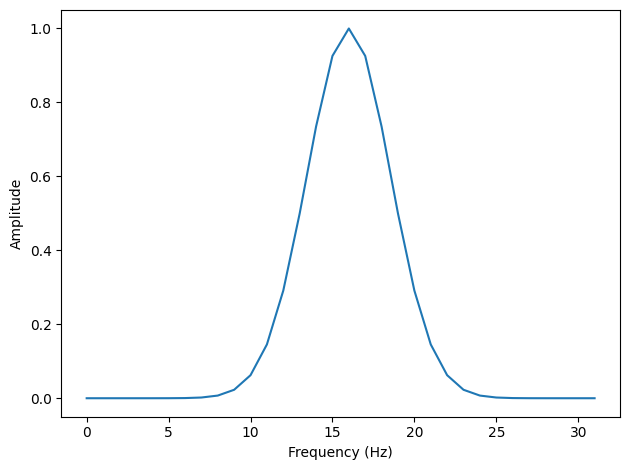

In [ ]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

### Функция для отображения окна Гаусса и его БПФ

Эта функция отображает гауссово окно и его спектр (БПФ) рядом, для наглядного сравнения.


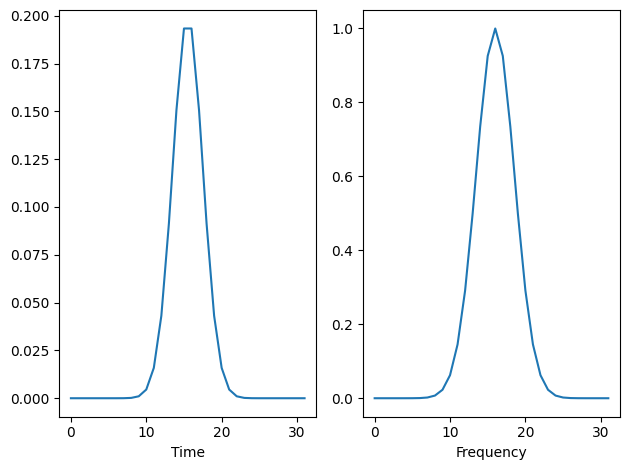

In [ ]:
def plot_gaussian(std):

    M = 32
    gaussian = g(M=M, std=std)
    gaussian /= sum(gaussian)

    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    decorate(xlabel='Time')

    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)

    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Frequency')
    plt.show()

plot_gaussian(2)

Теперь мы можем создать интерактивный элемент, который покажет, как изменяется форма окна Гаусса и его спектр в зависимости от значения `std`.

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.FloatSlider(min=0.1, max=10, value=2)
interact(plot_gaussian, std=slider);

interactive(children=(FloatSlider(value=2.0, description='std', max=10.0, min=0.1), Output()), _dom_classes=('…

### Обратная связь между шириной окна и его спектром

По мере увеличения значения `std`, гауссово окно становится шире, а его спектр (FFT) — уже.

С точки зрения непрерывной математики:

Если  
$$
f(x) = e^{-a x^2}
$$  
— это гауссов сигнал с нулевым средним и стандартным отклонением  
$$
\frac{1}{\sqrt{2a}},
$$  
то его преобразование Фурье:

$$
F(k) = \sqrt{\frac{\pi}{a}} \, e^{-\pi^2 k^2 / a}
$$  

тоже представляет собой гауссову функцию, но с другим стандартным отклонением —  
$$
\sqrt{\frac{a}{2\pi^2}}.
$$

Таким образом, между стандартными отклонениями временного и частотного представлений существует **обратная зависимость**:  
чем уже функция во времени, тем шире её спектр, и наоборот.


## Упражнение 8.3



Следуя примерам из главы, создадим звуковую волну длительностью 1 секунду с частотой дискретизации 44.1 кГц.

In [ ]:
from thinkdsp import SquareSignal

signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=44100)

Я создам несколько окон. Я выбрал стандартное отклонение для гауссового окна, чтобы оно было похоже на остальные.


In [ ]:
M = 15
std = 2.5

gaussian = g(M=M, std=std)
bartlett = np.bartlett(M)
blackman = np.blackman(M)
hamming = np.hamming(M)
hanning = np.hanning(M)

windows = [blackman, gaussian, hanning, hamming]
names = ['blackman', 'gaussian', 'hanning', 'hamming']

for window in windows:
    window /= sum(window)

Давайте посмотрим, как выглядят эти окна.


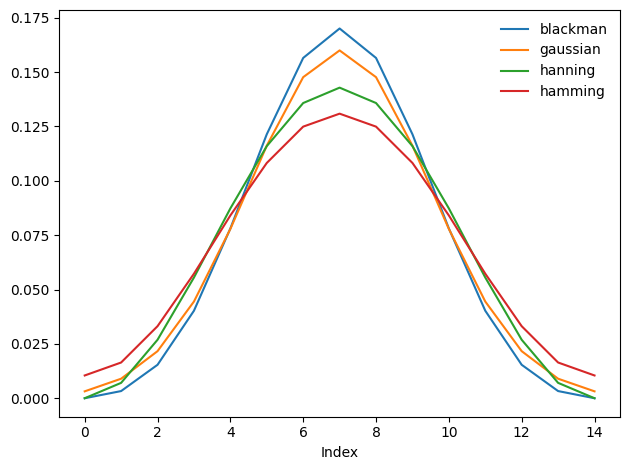

In [ ]:
for window, name in zip(windows, names):
    plt.plot(window, label=name)

decorate(xlabel='Index')

Они довольно похожи. Давайте посмотрим, как выглядят их БПФ:


In [ ]:
def zero_pad(array, n):
    """Extends an array with zeros.

    array: NumPy array
    n: length of result

    returns: new NumPy array
    """
    res = np.zeros(n)
    res[:len(array)] = array
    return res

In [ ]:
def plot_window_dfts(windows, names):
    """
    """
    for window, name in zip(windows, names):
        padded =  zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), label=name)

Тоже довольно похожи, но, похоже, что окно Хэмминга убывает быстрее всего, окно Блэкмана — медленнее всего, а окно Ханнинга имеет самые заметные побочные лепестки.


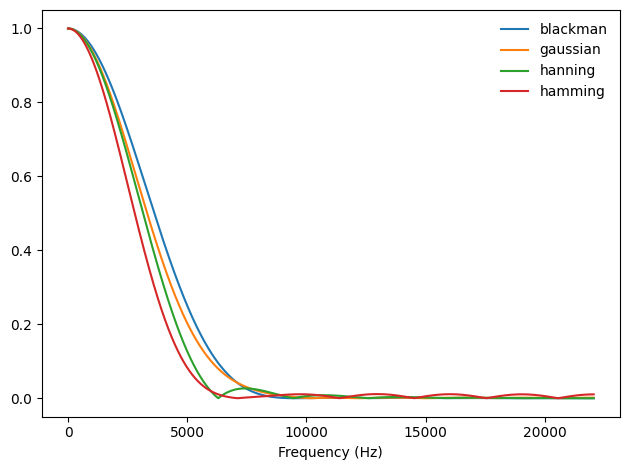

In [ ]:
plot_window_dfts(windows, names)
decorate(xlabel='Frequency (Hz)')

Вот тот же график, но с логарифмической шкалой по оси y.


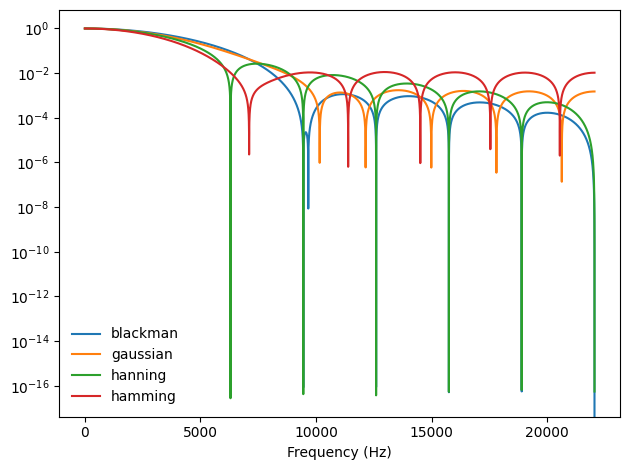

In [ ]:
plot_window_dfts(windows, names)
decorate(xlabel='Frequency (Hz)', yscale='log')

На логарифмической шкале видно, что окна Хэмминга и Ханнинга сначала убывают быстрее, чем другие два. Также окна Хэмминга и Гаусса, похоже, имеют наиболее устойчивые побочные лепестки. Окно Ханнинга, возможно, обладает лучшим сочетанием быстрой заглушенности и минимальных побочных лепестков.
